In [1]:
import numpy as np
import sisl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
import seaborn as sns

# 1. Set the high-level theme
sns.set_theme(style="whitegrid", context="paper")

# 2. Fine-tune specific font sizes and behaviors
plt.rcParams.update({
    "font.family": "serif",        # Use serif for a formal/academic look
    "font.size": 14,               # Base font size
    "axes.titlesize": 18,          # Subplot titles (your .set(title=...) calls)
    "axes.labelsize": 16,          # X and Y axis labels
    "xtick.labelsize": 12,         # Size of numbers on X-axis
    "ytick.labelsize": 12,         # Size of numbers on Y-axis
    "legend.fontsize": 14,         # Legend text
    'legend.title_fontsize': 18,
    
    "figure.titlesize": 20,        # Overall figure title
    "axes.labelpad": 10,           # Distance between label and axis
    "mathtext.fontset": "cm",      # Computer Modern (LaTeX look for math)
    "savefig.dpi": 300             # High-res exports
})

# Notes

- Make fat-BS -- see [dedicated notebook](show_fatbands_gnr.ipynb)
- calculates RSE vs. E for `[0.0, 0.1, 0.2]` (in scatter plot)
- Tiling (N) vs. on-site RSE

**OBS:** Move in $\mathrm{K}_x$ direction for bands

In [3]:
def plot_with_index(geometry):
    x,y,z = geometry.xyz.T
    cell = geometry.cell
    A, B = cell[:2, :2]
    
    points = np.array([
        [0, 0],
        A,
        A + B,
        B,
        [0, 0]
    ])
    uc_x, uc_y = points.T
    fig, ax = plt.subplots(1,1,figsize=(8,6))
    
    ax.scatter(x,y, marker='o', s=100, color='grey')
    # ax.axvline(x[1])
    # print(x[1], 1+b)
    
    for i in range(0, geometry.na):
        ax.annotate(text=i, xy=(x[i], y[i]), xytext=(x[i]+0.1, y[i]+0.1))
    ax.axis("equal")
    ax.plot(uc_x, uc_y, color="green")
    
    # xmax = np.max(geometry.cell[:, 0])
    # ymax = np.max(geometry.cell[:, 1])
    # ylim = (-ymax-1, ymax+1)
    # xlim = (-xmax-1, xmax+1)
    ax.set(
        # ylim=ylim,
        #    xlim=xlim, 
           xlabel="x",
           ylabel="y"
           )

# On-site for edge center + coupling  

complex128


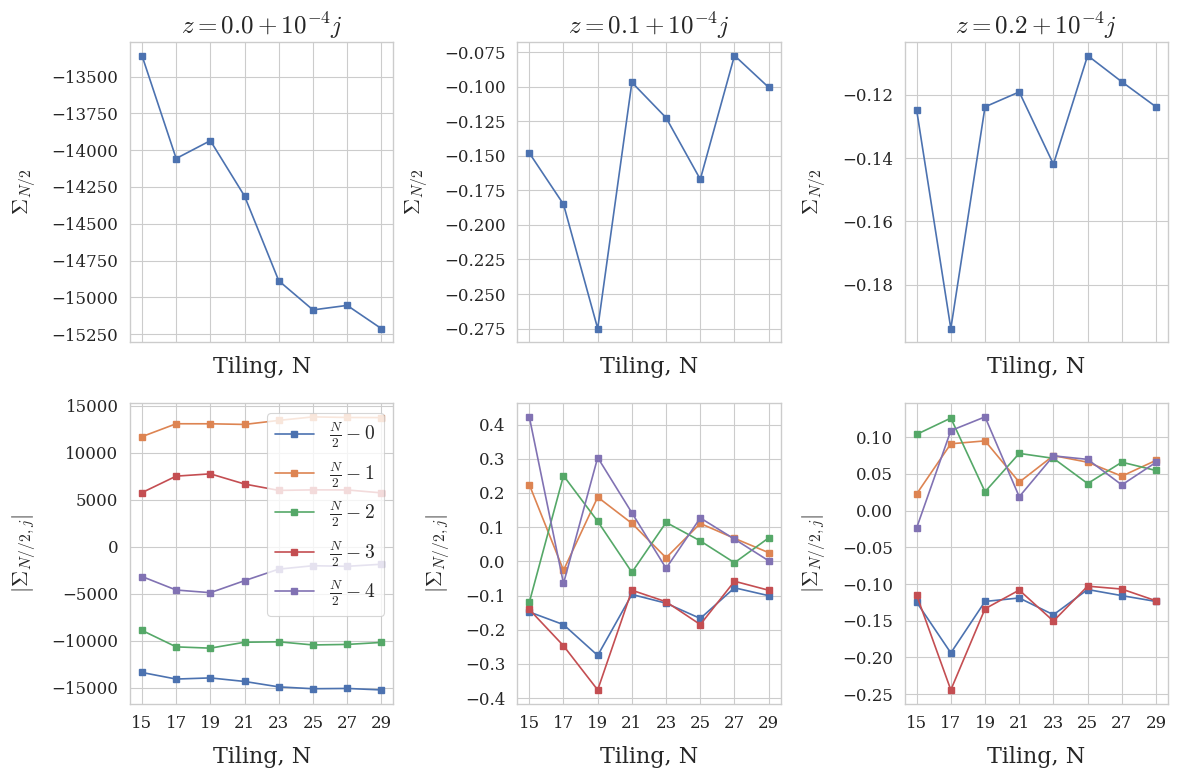

In [21]:
from pathlib import Path
file_path = Path.cwd().parent / 'overnight' / 'zigzag-edge.npz'
data = np.load(file_path)
onsite = data['onsite'][1:]
couple = data['couple'][1:]
tiles = data['tiles'][1:]
energies = data['energies']
eta = data['eta']
num_e = len(energies)
print(couple.dtype)

fig, axes = plt.subplots(2, num_e, figsize=(4*num_e, 8), sharex=True)
for j in range(num_e):
    axes[0, j].plot(tiles, onsite[:, j], color='b', linestyle='-', marker='s')
    axes[0, j].set(
        xlabel='Tiling, N', 
                   ylabel=r'$\Sigma_{N/2}$', title='$z = {:.1f} + 10^{{{:.0f}}}j$'.format(energies[j], np.log10(eta)))
    axes[0, j].set_xticks(tiles)
    
    NN = couple.shape[-1]
    axes[1, j].plot(tiles[:], np.imag(couple[:, j, NN//2:]), marker='s')
    axes[1, j].set(xlabel='Tiling, N', ylabel=r"$|\Sigma_{N//2,j}|$")
axes[1, 0].legend([rf"$\frac{{N}}{{2}}-{i}$" for i in range(NN//2)])   
fig.tight_layout()

In [5]:
order = 'yzx'
mapping = {'x': 0, 'y': 1, 'z': 2}
keys = [mapping[ax] for ax in reversed(order)]
keys

[0, 2, 1]

In [6]:
def sort_atoms(geom, order='xzy', atol=1e-2):
    xyz = geom.xyz.round(5)
    mask = np.isclose(xyz, 0, atol=atol)
    xyz = np.where(mask, 0, xyz)
    mapping = {'x': 0, 'y': 1, 'z': 2}
    axes = [mapping[ax] for ax in reversed(order)]
    # print(axes)
    idxs = np.lexsort([xyz[:, axes[0]], xyz[:, axes[1]], xyz[:, axes[2]]])
    return idxs
def make_device(bond=1.42, kind="armchair"):
    gr = sisl.geom.graphene(bond=bond, atoms="C", orthogonal=True) # returns *orthogonal* unitcell instead of primitive
    
    if kind == "armchair":
        idxs = sort_atoms(gr, order='xzy', atol=1e-2)
        gr = gr.sub(idxs)
        return gr
    
    elif kind == "zigzag":
        gr = gr.rotate([180, [0,1,0]]).rotate([-90, [0,0,1]])
        idxs = sort_atoms(gr, order='xzy', atol=1e-2)
        # print(idxs)
        cell = gr.cell[[1,0,2], :]
        gr.set_lattice(cell)
        gr.set_nsc([3,3,1])
        gr = gr.sub(idxs)
        return gr

# Global parameters

In [7]:
# Geometry params
BOND = 1.42
OUTER_R = BOND

PHI = np.pi/3
B = BOND*np.cos(PHI)
INNER_R = B


## edge type
KIND = 'zigzag'

## TB Hamiltonian params
R = (0.1, BOND+2e-2)
T = (0.0, -2.7)

# tiling and RSE params
N0 = 4
N1 = 4
ETA = 1e-4
NK1 = 400
# ETAS = np.logspace(-1, -5, num=5)


## Data points for number of energies in pdos and number of divisions in bandsstructure path
NUM_E = 1_000
NUM_K = 300


## points and labels for BS plots
BAND_POINTS = [
    [0, 0, 0],
    [0.5, 0, 0],
]
BAND_LABELS = [
    r"$\Gamma$", 
    r'$\mathrm{K}_x$', 
]


## Global parameters (dependent on previous)

In [8]:
# generate UC 00
GRAPHENE = make_device(BOND, KIND)

# # create hamiltonian for UC 00
HAM0 = sisl.Hamiltonian(GRAPHENE)
HAM0.construct([R, T])

# Initialise RSE from the H of UC 00
RSE = sisl.RealSpaceSE(HAM0, 0, 1, [N0, N1, 1])
RSE.setup(eta=ETA, bz=sisl.MonkhorstPack(HAM0, [1, NK1, 1]))

# Get the indices for the electrode 
HAM_ELEC, ELEC_IDX = RSE.real_space_coupling(ret_indices=True)
# HAM_NN = HAM0.tile(N0, 0).tile(N1, 1)
HAM_NN = RSE.real_space_parent()

# SORT_IDX = sort_atoms(HAM_NN)
# HAM_NN.sub(SORT_IDX)

## if construct is not run again, the BS is constant along K path
# HAM_NN.construct([R,T])
XYZ = HAM_NN.xyz
HAM_NN.set_nsc([3,1,1])


## make a list of indices with the electrode being the first elements
ATOMS_IDX = np.arange(HAM_NN.na)
DEVICE_IDX = np.delete(ATOMS_IDX, ELEC_IDX)
ALL_IDX = np.concat([ELEC_IDX, DEVICE_IDX])


BANDS = sisl.BandStructure(HAM_NN, points=BAND_POINTS, divisions=NUM_K, names=BAND_LABELS)
LK, KT, KL = BANDS.lineark(ticks=True)

EIGS = BANDS.apply.array.eigh()
ENERGIES = np.linspace(EIGS.min(), EIGS.max(), NUM_E)

ES = HAM_NN.eigenstate()
PDOS = ES.PDOS(ENERGIES).squeeze()

warn:0: SislWarning: Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.


In [9]:
site = 5
closest = np.linalg.norm(XYZ[site,:] - XYZ, axis=1).round(15)
HAM_NN.geometry.plot(axes='xy',
                     atoms_style=[
                         dict(atoms=closest <= BOND, color='red'),
                         dict(atoms=site, color='blue',),
                        #  dict(atoms=7, color='green'),
                         
                     ]
                     )
# print(closest[7])

# Self-energy calculations

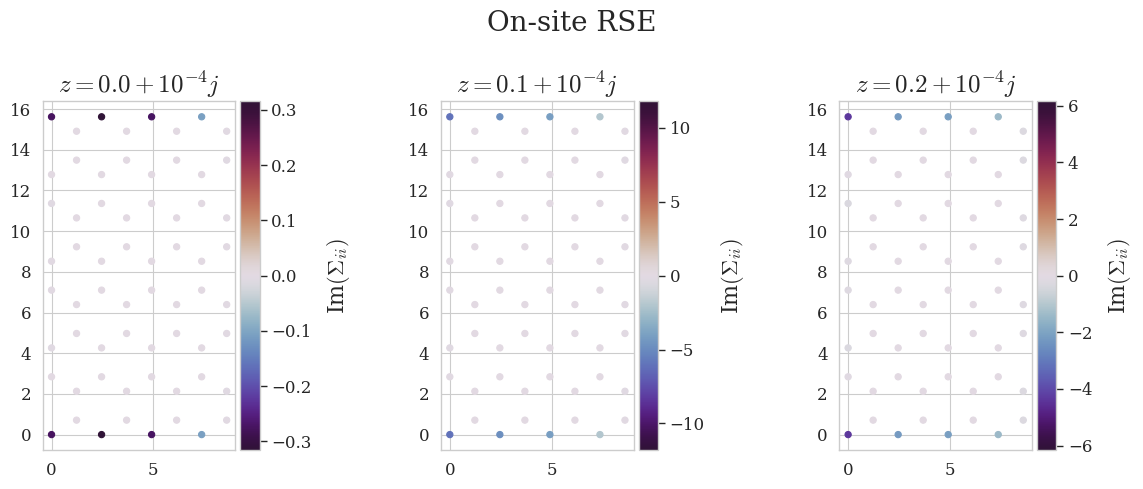

In [10]:
plot_uc = False
from mpl_toolkits.axes_grid1 import make_axes_locatable

x,y,_ = XYZ.T
fig, axes = plt.subplots(1,3, figsize=(12,5))
for i, en in enumerate([0.0, 0.1, 0.2]):
    Z = en + ETA*1j
    RSE_MAT = RSE.self_energy(Z)
    RSE_DIAG = np.diag(RSE_MAT)
    vmax = np.abs(RSE_DIAG).max()
    vmin = -vmax
    
    if plot_uc: # plot unit cell
        uc_x, uc_y = HAM_NN.cell[:2, :2]
        uc = np.array([[0,0], uc_x, uc_x+uc_y, uc_y, [0, 0]])
        uc_x, uc_y = uc.T
        axes[i].plot(uc_x, uc_y, 'g')
    
    sc = axes[i].scatter(x,y, c=np.imag(RSE_DIAG), s=20, cmap='twilight_shifted', vmin=vmin, vmax=vmax)
    divider = make_axes_locatable(axes[i])
    cax = divider.append_axes('right', size='10%', pad=0.05)
    cbar = fig.colorbar(sc, cax)
    cbar.set_label(r'Im$(\Sigma_{ii})$')
    axes[i].axis('scaled')
    axes[i].set_title('$z = {:.1f} + 10^{{{:.0f}}}j$'.format(en, np.log10(ETA)))
    
fig.suptitle("On-site RSE")
fig.tight_layout()

# BS using global `HAM_NN`

**Issues:**  
- using the RSE hamiltonian breaks eigenvalues (will be constant for all k, due to sampling in transverse direction?)
- using tiling creates valid looking BS, but edge states not on fermi-level - why???

**Possible solution:**
- for each k-point, extract `HAM_NN.Hk(k=kpt, format="array")` and get corresponding eigval and eigvec/state

499


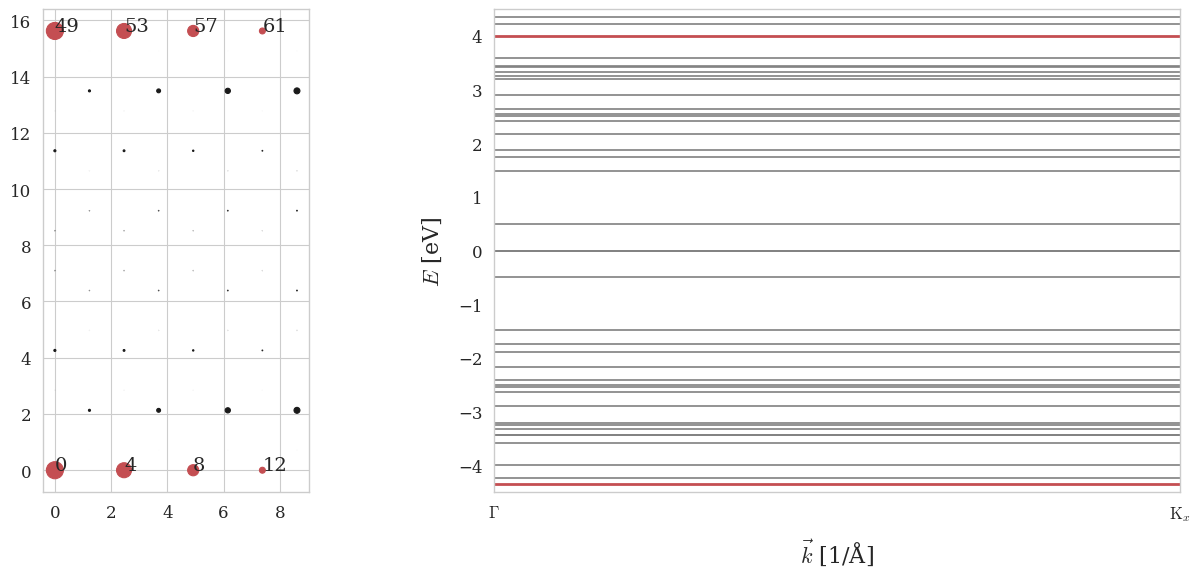

In [11]:
y_coords = XYZ[:, 1]
ymin = y_coords.min()
ymax = y_coords.max()
tol = INNER_R


top_edge_indices, = np.where(np.abs(y_coords - ymax) < tol)
bottom_edge_indices,  = np.where(np.abs(y_coords - ymin) < tol)

edges = np.concatenate([bottom_edge_indices, top_edge_indices])
not_edges = np.delete(np.arange(len(y_coords)), edges)

energy = 0.0
ener_idxs, = np.where(np.isclose(ENERGIES, energy, atol=1e-2, rtol=1e-4))
E_idx = ener_idxs[0]
print(E_idx)


## plotting
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].scatter(XYZ[edges, 0], XYZ[edges, 1], s=PDOS[edges, E_idx]*1e2, c='r')
axes[0].scatter(XYZ[not_edges, 0], XYZ[not_edges, 1], s=PDOS[not_edges, E_idx]*1e2, c='k')
for i in edges:
    x, y, _ = XYZ[i, :]
    axes[0].annotate(xy=(x, y), text=i)
axes[0].axis('scaled')


# axes[1].plot(lk, eigs[:, nbands//2-15:nbands//2+15], color="k")
axes[1].plot(LK, EIGS[:, not_edges], color="grey")
axes[1].plot(LK, EIGS[:, edges], color="r", lw=2)

# axes[1].axhline(ENERGIES[E_idx], lw=3, linestyle='--')
axes[1].set(xticks=KT, xticklabels=KL, xlim=(LK[0], LK[-1]), xlabel=r"$\vec{k}$ [1/Å]", ylabel="$E$ [eV]")
axes[1].set_ylim(-4.5, 4.5)
axes[1].grid()
fig.tight_layout()

# BS calculations using graphene_nanoribbon

499


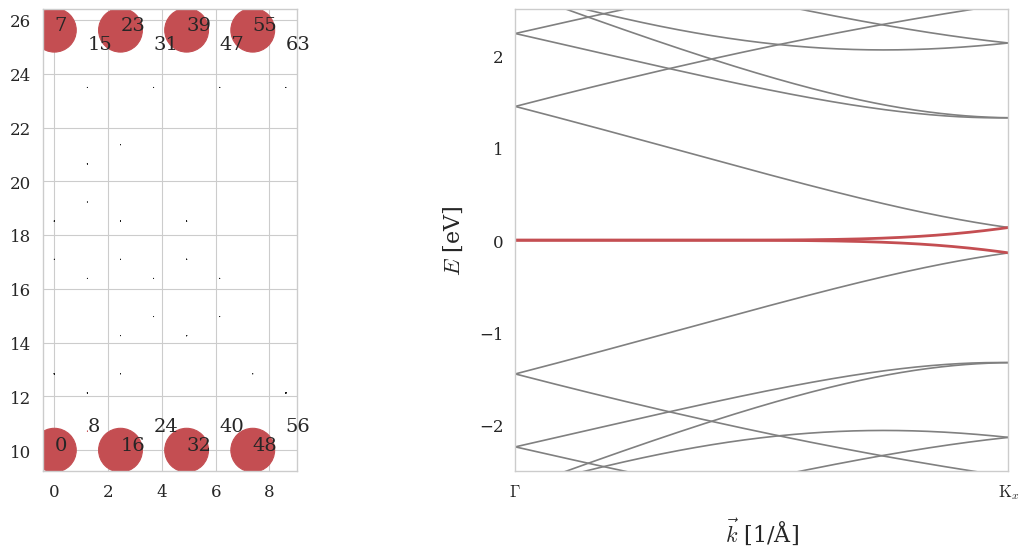

In [12]:
gr = sisl.geom.graphene_nanoribbon(width=N1*2, bond=BOND, kind='zigzag')
gr = gr.tile(N0,0)
Ham = sisl.Hamiltonian(gr)

r = (0.1, BOND + 1e-2)
t = (0.0, -2.7)
Ham.construct([r, t])
Ham.set_nsc([3,1,1])

bands = sisl.BandStructure(Ham, points=BAND_POINTS, divisions=NUM_K, names=BAND_LABELS)
lk, kt, kl = bands.lineark(ticks=True)

eigs = bands.apply.array.eigh()
# es = HAM_NN.eigenstate()
energies = np.linspace(eigs.min(), eigs.max(), NUM_E)
es = Ham.eigenstate()
pdos = es.PDOS(energies).squeeze()


xyz = HAM_NN.xyz
xyz = Ham.xyz
y_coords = xyz[:, 1]
y_max = y_coords.max()
y_min = y_coords.min()
tol = BOND*np.sqrt(3)/2

top_edge_indices, = np.where(np.abs(y_coords - y_max) < tol)
bottom_edge_indices,  = np.where(np.abs(y_coords - y_min) < tol)

edges = np.concatenate([bottom_edge_indices, top_edge_indices])
not_edges = np.delete(np.arange(len(y_coords)), edges)

ener = 0.0
e_idxs, = np.where(np.isclose(energies, ener, atol=1e-2, rtol=1e-2))
E_idx = e_idxs[0]
print(E_idx)


fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].scatter(xyz[edges, 0], xyz[edges, 1], s=pdos[edges, E_idx]*1e3, c='r')
axes[0].scatter(xyz[not_edges, 0], xyz[not_edges, 1], s=pdos[not_edges, E_idx]*1e3, c='k')
for i in edges:
    x, y, _ = xyz[i, :]
    axes[0].annotate(xy=(x, y), text=i)
axes[0].axis('scaled')


# axes[1].plot(lk, eigs[:, nbands//2-15:nbands//2+15], color="k")
axes[1].plot(lk, eigs[:, not_edges], color="grey")
axes[1].plot(lk, eigs[:, edges], color="r", lw=2)

# axes[1].axhline(energies[E_idx], lw=3, linestyle='--')
axes[1].set(xticks=kt, xticklabels=kl, xlim=(lk[0], lk[-1]), xlabel=r"$\vec{k}$ [1/Å]", ylabel="$E$ [eV]")
axes[1].set_ylim(-2.5,2.5)
axes[1].grid()

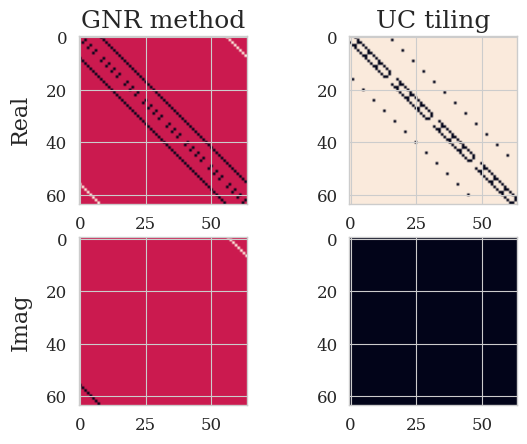

In [13]:
fig, ax= plt.subplots(2,2)
p = 1

ax[0,0].set_title("GNR method")
ax[0,1].set_title("UC tiling")

ax[0,0].set_ylabel("Real")
ax[0,0].imshow(np.real(
    Ham.Hk(format='array', k=BAND_POINTS[p])
))
ax[0,1].imshow(np.real(
    HAM_NN.Hk(format='array', k=BAND_POINTS[p])
))

ax[1,0].set_ylabel("Imag")
ax[1,0].imshow(np.imag(
    Ham.Hk(format='array', k=BAND_POINTS[p])
))
ax[1,1].imshow(np.imag(
    HAM_NN.Hk(format='array', k=BAND_POINTS[p])
))


# ax[2,0].imshow(np.abs(
#     Ham.Hk(format='array', k=BAND_POINTS[p])
# ))
# ax[2,1].imshow(np.abs(
#     HAM_NN.Hk(format='array', k=BAND_POINTS[p])
# ))

# ax[2,0].set_ylabel('Abs')


# Fatbands

## Using built-in

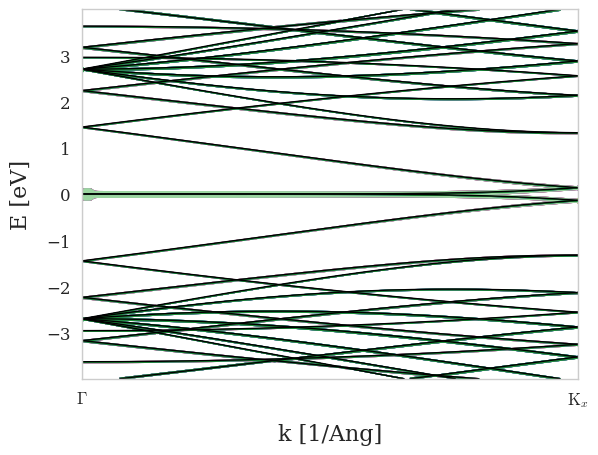

In [14]:
fatplot=bands.plot.fatbands(Erange=[-4, 4], backend="matplotlib")
fatplot.split_orbs(on="atoms", only=edges)

In [15]:
# numk = 300
# gr = sisl.geom.graphene_nanoribbon(width=N1*2, bond=BOND, kind=KIND)
# # gr = sisl.geom.graphene(bond=BOND)
# # gr = gr.tile(10,1)
# gr = gr.tile(N0,0)
# HAM = sisl.Hamiltonian(gr)

# r = (0.1, 1.44)
# t = (0.0, -2.7)
# HAM.construct([r,t])
# HAM.set_nsc([3,1,1])

# BAND_POINTS = [
#     [0, 0, 0],
#     [0.5, 0, 0],
    
# ]
# BAND_LABELS = [
#     r"$\Gamma$", 
#     # r'M', 
#     # r"$\Gamma$", 
#     r'K_x', 
#     # r'$\Gamma$'
# ]

# bands = sisl.BandStructure(HAM, points=BAND_POINTS, divisions=numk, names=BAND_LABELS)
# lk, kt, kl = bands.lineark(ticks=True)

# xyz = gr.xyz
# y_coords = xyz[:, 1]
# y_max = y_coords.max()
# y_min = y_coords.min()
# tol = BOND*np.sqrt(3)/2

# top_edge_indices, = np.where(np.abs(y_coords - y_max) < tol)
# bottom_edge_indices,  = np.where(np.abs(y_coords - y_min) < tol)

# edges = np.concatenate([bottom_edge_indices, top_edge_indices])

# not_edges = np.delete(np.arange(len(y_coords)), edges)

# E = 2
# idxs, = np.where(np.isclose(energies, E, atol=1e-2, rtol=1e-2))

# bands = sisl.BandStructure(Ham, points=band_points, divisions=numk, names=band_labels)
# lk, kt, kl = bands.lineark(ticks=True)
kpts = bands.k

eigenenergies = np.zeros(shape=(NUM_K, Ham.na))
eigenstates = np.zeros(shape=(NUM_K, Ham.na, Ham.na), dtype=np.complex128)
edge_weights = np.zeros_like(eigenenergies)

bulk_weights = np.zeros_like(edge_weights)

for i, k in enumerate(kpts):
    Hk = Ham.Hk(k=k, format="array")
    energy, state = np.linalg.eigh(Hk)
    eigenenergies[i, :] = energy
    eigenstates[i, :, :] = state
    
    # state[i, :] corresponds to eigenenergy energy[i]
    c_ik_n = np.abs(state)**2
    edge_contribution = np.sum(c_ik_n[edges], axis=0)
    bulk_contribution = np.sum(c_ik_n[not_edges], axis=0)
    edge_weights[i, :] = edge_contribution
    bulk_weights[i, :] = bulk_contribution
    
print(edge_weights.shape)

(300, 64)


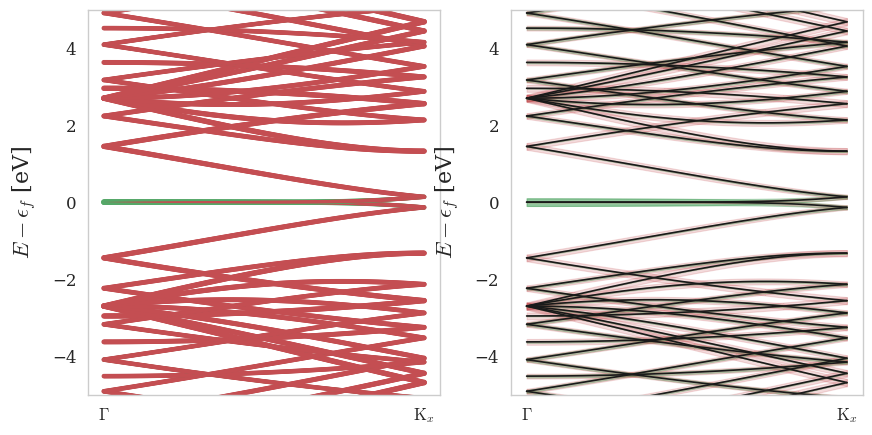

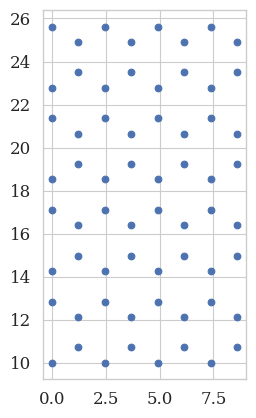

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

all_bands = np.arange(Ham.na)
bands_to_plot = np.delete(all_bands, edges)[25:45]

axes[1].plot(lk, eigenenergies, c='k')
scale_factor = 0.1
for n in all_bands:
    upper = eigenenergies[:, n] + (edge_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (edge_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='g',
                    alpha=0.4,
                    edgecolor="g")
    
    upper = eigenenergies[:, n] + (bulk_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (bulk_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='r',
                    alpha=0.2,
                    edgecolor="r")

for n in range(Ham.na):
    axes[0].scatter(lk, eigenenergies[:, n],
               s=edge_weights[:, n]*1e1,
               c='g'
            #    c=weights[:, n],
            #    cmap='',
            #    edgecolor='g'
               )
    axes[0].scatter(lk, eigenenergies[:, n],
               s=bulk_weights[:, n]*1e1,
               c='r'
            #    c=weights[:, n],
            #    cmap='',
            #    edgecolor='g'
               )

for ax in axes:
    ax.set_ylim((-5,5))
    ax.set_ylabel(r"$E - \epsilon_f$ [eV]")
    ax.set_xticks(kt, kl)
    ax.grid()
    
fig, ax = plt.subplots()

ax.scatter(gr.xyz[:, 0], gr.xyz[:, 1])
ax.axis('scaled');
    


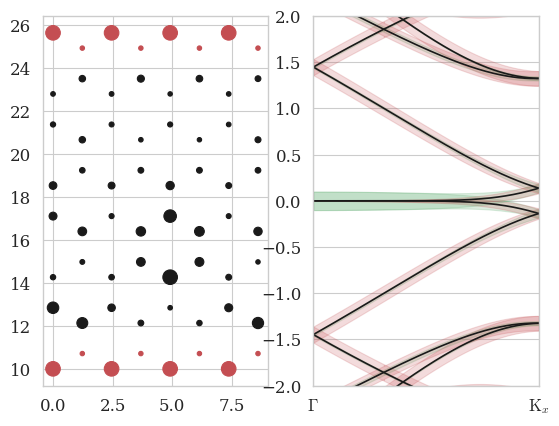

In [17]:
kpts = bands.k

eigenenergies = np.zeros(shape=(NUM_K, Ham.na))
eigenstates = np.zeros(shape=(NUM_K, Ham.na, Ham.na), dtype=np.complex128)
edge_weights = np.zeros_like(eigenenergies)

bulk_weights = np.zeros_like(edge_weights)

for i, k in enumerate(kpts):
    Hk = Ham.Hk(k=k, format="array")
    energy, state = np.linalg.eigh(Hk)
    eigenenergies[i, :] = energy
    eigenstates[i, :, :] = state
    
    # state[i, :] corresponds to eigenenergy energy[i]
    c_ik_n = np.abs(state)**2
    edge_contribution = np.sum(c_ik_n[edges], axis=0)
    bulk_contribution = np.sum(c_ik_n[not_edges], axis=0)
    edge_weights[i, :] = edge_contribution
    bulk_weights[i, :] = bulk_contribution


NORM = lambda mat: 10 + 100*(mat - mat.min()) / (mat.max() - mat.min())


E = 0
energy_idxs, = np.where(np.isclose(energies, E, atol=1e-2, rtol=1e-2))
E_idx = energy_idxs[0]


fig, axes = plt.subplots(1,2)
axes[0].scatter(*Ham.xyz[not_edges, :2].T, s=NORM(pdos[not_edges, E_idx]), c='k')
axes[0].scatter(*Ham.xyz[edges, :2].T,     s=NORM(pdos[edges, E_idx]), c='r')

axes[1].plot(lk, eigenenergies, c='k')
scale_factor = 0.1
for n in all_bands:
    upper = eigenenergies[:, n] + (edge_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (edge_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='g',
                    alpha=0.2,
                    edgecolor="g")
    
    upper = eigenenergies[:, n] + (bulk_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (bulk_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='r',
                    alpha=0.2,
                    edgecolor="r")
    
ylim = 2
axes[1].set_ylim(-ylim, ylim)
axes[1].set_xlim(lk[0], lk[-1])
axes[1].set_xticks(kt, kl)

In [18]:
Ham.xyz[:, :2].shape, pdos[:, E_idx].shape

((64, 2), (64,))

In [19]:
pdos[:, E_idx]

array([9.94177048e-01, 2.37847485e-30, 1.96653233e-31, 9.11419572e-31,
       8.31764314e-31, 1.64704177e-31, 5.05993448e-32, 9.94177048e-01,
       2.24588541e-31, 2.10182596e-30, 8.75998907e-32, 1.18057131e-30,
       2.44480641e-31, 4.67598137e-31, 4.78145044e-31, 2.22650631e-32,
       9.94177048e-01, 7.83768133e-31, 2.51146991e-31, 1.32091832e-31,
       5.84004070e-31, 1.22269520e-31, 6.10311032e-32, 9.94177048e-01,
       2.45413099e-31, 2.92896857e-31, 1.19892812e-30, 1.46450720e-30,
       2.95045162e-31, 3.05133661e-32, 6.41401875e-31, 5.19556823e-32,
       9.94177048e-01, 3.44289341e-32, 4.08267391e-30, 2.90418236e-30,
       1.04429975e-30, 1.40665358e-31, 1.09263410e-32, 9.94177048e-01,
       1.87321441e-31, 2.16520318e-31, 1.25196721e-30, 1.59890870e-30,
       3.03537104e-31, 5.18361117e-33, 5.12828675e-31, 3.23109249e-32,
       9.94177048e-01, 9.44349366e-31, 3.19321303e-31, 1.05376321e-31,
       3.22171116e-31, 4.87107813e-32, 3.90442348e-32, 9.94177048e-01,
      